# Unmasking Political Question Evasions

Team: **MLLJLS** \
\
Team members:
*   Marta Leš; 0036548040
*   Ljubomir Jerončić; 0036552755
*   Luka Špiljak; 0036546275



#### 0. Imports

In [ ]:
import torch
import gc
import time
import numpy as np
import pandas as pd
from google.colab import userdata
from openai import OpenAI
from torch.utils.data import DataLoader, Dataset
from transformers import RobertaTokenizer, RobertaForSequenceClassification
from torch.optim import AdamW
from tqdm import tqdm
from datasets import load_dataset, Dataset as HFDataset, DatasetDict
from sklearn.metrics import f1_score
import numpy as np
from sklearn.model_selection import train_test_split

In [ ]:
torch.cuda.empty_cache()

In [ ]:
%%capture
APIKEY = userdata.get('APIKEY')
%env OPENAI_API_KEY=$APIKEY

## 1. Setup and Data preparation

In [ ]:
ds = load_dataset("ailsntua/QEvasion")

print("sample 0: ", ds["train"][0])
print("features: ", ds["train"].features)

#print(len(ds["test"]))


df = pd.DataFrame(ds["train"])

print(ds["train"][1])


print("\n", df.groupby("clarity_label")["evasion_label"].value_counts())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/12.7k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/3.90M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/3448 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/308 [00:00<?, ? examples/s]

sample 0:  {'title': "The President's News Conference in Hanoi, Vietnam", 'date': 'September 10, 2023', 'president': 'Joseph R. Biden', 'url': 'https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-hanoi-vietnam-0', 'question_order': 1, 'interview_question': 'Q. Of the Biden administration. And accused the United States of containing China while pushing for diplomatic talks.How would you respond to that? And do you think President Xi is being sincere about getting the relationship back on track as he bans Apple in China?', 'interview_answer': "Well, look, first of all, theI am sincere about getting the relationship right. And one of the things that is going on now is, China is beginning to change some of the rules of the game, in terms of trade and other issues.And so one of the things we talked about, for example, is that they're now talking about making sure that no Chineseno one in the Chinese Government can use a Western cell phone. Those kinds of things.And so, 

Added mapping dictionaries to class indexes for the evasion clarity labels, and a dictionary to map those 9 labels to the 3 direct clarity labels

In [ ]:
evasion_mapping = {
    'Explicit': 0, 'Implicit': 1, 'Dodging': 2, 'Deflection': 3,
    'Partial/half-answer': 4, 'General': 5,
    'Declining to answer': 6, 'Claims ignorance': 7, 'Clarification': 8
}

clarity_mapping_3class = {
    'Explicit': 0,           # Clear Reply
    'Implicit': 1,           # Ambivalent
    'Dodging': 1,
    'Deflection': 1,
    'Partial/half-answer': 1,
    'General': 1,
    'Declining to answer': 2, # Clear Non-Reply
    'Claims ignorance': 2,
    'Clarification': 2,
}

Custom Dataset class

In [ ]:
class EvasionDataset(Dataset):
  def __init__(self, texts, labels, tokenizer, max_length=512):
      self.max_length = max_length
      self.texts, self.labels = [], []
      self.tokenizer = tokenizer
      for text, label in zip(texts, labels):
          inputs = tokenizer(
              text,
              return_tensors='pt',
              padding='max_length',
              max_length=self.max_length
          )
          if len(inputs['input_ids'][0]) <= self.max_length:
              self.texts.append(text)
              self.labels.append(label)
      print(f"Kept {len(self.texts)} / {len(texts)} samples after length filter")

  def __len__(self):
      return len(self.texts)

  def __getitem__(self, idx):
      inputs = self.tokenizer(
          self.texts[idx],
          return_tensors='pt',
          padding='max_length',
          max_length=self.max_length
      )
      return inputs, torch.tensor(self.labels[idx])

Method for plotting the confusion matrix

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_confusion_matrix(y_true, y_pred, experiment_name):
    if experiment_name == "evasion_based_clarity":
        class_names = [
            'Explicit', 'Implicit', 'Dodging', 'Deflection',
            'Partial/half-answer', 'General', 'Declining to answer',
            'Claims ignorance', 'Clarification'
        ]
        figsize = (11, 9)
    elif experiment_name == "direct_clarity":
        class_names = ['Clear Reply (0)', 'Ambivalent (1)', 'Clear Non-Reply (2)']
        figsize = (7, 6)
    else:
        class_names = [str(i) for i in np.unique(y_true)]
        figsize = (8, 6)


    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=figsize)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=class_names,
        yticklabels=class_names,
        square=True,
        cbar_kws={"shrink": .8}
    )

    plt.title(f'Confusion Matrix\nExperiment: {experiment_name}', fontsize=14, pad=15)
    plt.ylabel('Actual Label', fontsize=12, labelpad=10)
    plt.xlabel('Predicted Label', fontsize=12, labelpad=10)

    if experiment_name == "evasion_based_clarity":
        plt.xticks(rotation=45, ha='right')
        plt.yticks(rotation=0)
    else:
        plt.xticks(rotation=0)
        plt.yticks(rotation=0)

    plt.tight_layout()

    plt.savefig(f"confusion_matrix_{experiment_name}.png", dpi=300)
    plt.show()

Methods for training and evaluating an encoder. You can choose encoder architecture, as well as which features to use in the input. The "basic mode" uses the (interview_question, interview_answer, question) combination, while the other two options replace the interview_question with an LLM generated summary.

In [ ]:
def get_texts_and_labels(split, experiment, label_map, feature_setup="basic"):
    texts, labels = [], []
    for row in split:

        label = row["evasion_label"]

        if not label or label not in label_map:
              continue

        # Original input format: full question + answer + subquestion
        if feature_setup=="basic":
          text = (f"Full Question: {row['interview_question']}\n\n"
                  f"Answer: {row['interview_answer']}\n\n"
                  f"Question: {row['question']}")
        elif feature_setup=="gpt3.5_summary":
          text = (f"Question: {row['question']}\n\n"
                  f"Answer: {row['interview_answer']}\n\n"
                  f"Summary: {row['gpt3.5_summary']}")
        elif feature_setup=="5.4-nano_summary":
          text = (f"Question: {row['question']}\n\n"
                  f"Answer: {row['interview_answer']}\n\n"
                  f"Summary: {row['5.4-nano_summary']}") #CHANGE AFTER ADDING THE FIELD IF necessary

        texts.append(text)
        labels.append(label_map[label])
    return texts, labels

def configure(experiment, model_name):
  if experiment == "evasion_based_clarity":
      num_labels = 9
      label_map = evasion_mapping
  elif experiment == "direct_clarity":
      num_labels = 3
      label_map = clarity_mapping_3class

  if 'roberta' in model_name:
    tokenizer = RobertaTokenizer.from_pretrained(model_name)
    model = RobertaForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to("cuda")
    max_size = 512

  elif "xlnet" in model_name:
      # Load pre-trained XLNet model and tokenizer
      from transformers import XLNetTokenizer, XLNetForSequenceClassification#, AdamW
      tokenizer = XLNetTokenizer.from_pretrained(model_name)
      model = XLNetForSequenceClassification.from_pretrained(model_name, num_labels=num_labels).to("cuda")
      max_size = 512

  elif "deberta" in model_name:
      from transformers import DebertaTokenizer, DebertaForSequenceClassification#, AdamW
      tokenizer = DebertaTokenizer.from_pretrained(model_name)
      model = DebertaForSequenceClassification.from_pretrained(model_name, num_labels=num_labels, ignore_mismatched_sizes=True).to("cuda").float()
      max_size = 512

  return num_labels, label_map, tokenizer, model, max_size

def collate_fn(batch):
    inputs, labels = zip(*batch)
    return {
        'input_ids':      torch.stack([x['input_ids'].squeeze() for x in inputs]),
        'attention_mask': torch.stack([x['attention_mask'].squeeze() for x in inputs]),
        'labels':         torch.tensor(labels)
    }


def run_experiment(experiment, model_name, dataset, feature_setup="basic", plot_cm = True, file_prefix = "baseline", num_epochs = 50):

  num_labels, label_map, tokenizer, model, max_size = configure(experiment, model_name)

  all_texts, all_labels = get_texts_and_labels(dataset["train"], experiment, label_map, feature_setup)
  print(f"Total samples: {len(all_texts)}")

  # Match original split: first 2700 train, rest val
  train_texts, val_texts, train_labels, val_labels = train_test_split(
      all_texts,
      all_labels,
      test_size=0.2,
      stratify=all_labels,
      random_state=42
  )

  train_dataset = EvasionDataset(train_texts, train_labels, tokenizer, max_length=max_size)
  val_dataset   = EvasionDataset(val_texts,   val_labels, tokenizer,  max_length=max_size)

  print(f"Train labels: {train_dataset.labels}, Val labels: {val_dataset.labels}")

  train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True,  collate_fn=collate_fn)
  val_dataloader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, collate_fn=collate_fn)

  print(f"Train batches: {len(train_dataloader)}, Val batches: {len(val_dataloader)}")


  optimizer = AdamW(model.parameters(), lr=1e-5)

  prev_train_loss = float('inf')
  best_macro_f1 = 0.0
  out_file = f"{file_prefix}-{model_name.split('/')[-1]}-qaevasion-{experiment}"

  all_preds, all_labels_list = [], []


  for epoch in range(num_epochs):
      model.train()
      train_loss = 0.0
      for batch in tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{num_epochs} - Training'):
          input_ids      = batch['input_ids'].to("cuda")
          attention_mask = batch['attention_mask'].to("cuda")
          labels         = batch['labels'].to("cuda")

          outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
          loss = outputs.loss
          loss.backward()
          torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
          optimizer.step()
          optimizer.zero_grad()
          train_loss += loss.item()

      # VAL
      model.eval()
      val_loss = 0.0
      all_preds, all_labels_list = [], []

      with torch.no_grad():
          for batch in tqdm(val_dataloader, desc=f'Epoch {epoch+1}/{num_epochs} - Validation'):
              input_ids      = batch['input_ids'].to("cuda")
              attention_mask = batch['attention_mask'].to("cuda")
              labels         = batch['labels'].to("cuda")

              outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
              val_loss += outputs.loss.item()

              preds = torch.argmax(outputs.logits, dim=1)
              all_preds.extend(preds.cpu().numpy())
              all_labels_list.extend(labels.cpu().numpy())

      avg_train_loss = train_loss / len(train_dataloader)
      avg_val_loss   = val_loss   / len(val_dataloader)
      macro_f1       = f1_score(all_labels_list, all_preds, average='macro')

      print(f"Epoch {epoch+1}/{num_epochs} — Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Macro F1: {macro_f1:.4f}")

      if macro_f1 > best_macro_f1:
          best_macro_f1 = macro_f1
          best_preds = all_preds.copy() # Store the best predictions
          best_labels = all_labels_list.copy() # Store the best labels
          #model.save_pretrained(out_file)
          #tokenizer.save_pretrained(out_file)
          #print(f"New best model saved with Macro F1: {best_macro_f1:.4f}")

      if abs(prev_train_loss - avg_train_loss) < 0.005:
          print(f"Early stopping: Train loss change {abs(prev_train_loss - avg_train_loss):.4f} is less than 0.005")
          break
      prev_train_loss = avg_train_loss

  print(f"Training finished. Best Macro F1: {best_macro_f1:.4f}. Model is saved at {out_file}")

  if plot_cm:
    plot_confusion_matrix(best_labels, best_preds, experiment)

  return best_labels, best_preds





#RQ1

Running a baseline model that takes in (question, interview_answer, gpt3.5_summary) as inputs for both evasion based classification, and direct clarity classification

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total samples: 3448
Kept 1432 / 2758 samples after length filter
Kept 357 / 690 samples after length filter
Train labels: [0, 2, 3, 2, 2, 0, 1, 2, 0, 0, 0, 5, 0, 7, 5, 3, 2, 7, 0, 0, 8, 2, 6, 0, 6, 0, 2, 2, 8, 4, 2, 0, 0, 3, 2, 0, 0, 5, 2, 2, 7, 1, 0, 3, 7, 5, 0, 2, 3, 2, 2, 1, 8, 2, 0, 0, 2, 1, 0, 2, 1, 2, 7, 0, 8, 2, 0, 0, 1, 5, 8, 2, 0, 6, 2, 2, 8, 5, 3, 0, 3, 1, 5, 0, 0, 2, 2, 2, 3, 0, 4, 8, 2, 0, 2, 0, 5, 6, 4, 5, 4, 1, 0, 0, 3, 8, 3, 2, 0, 1, 6, 5, 2, 1, 1, 3, 0, 0, 6, 0, 2, 3, 0, 5, 2, 2, 5, 2, 0, 2, 2, 0, 0, 3, 0, 0, 0, 2, 2, 2, 2, 3, 6, 2, 2, 2, 1, 0, 6, 8, 8, 5, 0, 6, 5, 0, 6, 5, 6, 0, 8, 0, 3, 2, 0, 0, 2, 0, 8, 1, 2, 2, 1, 2, 7, 5, 1, 7, 5, 7, 7, 2, 4, 0, 8, 0, 0, 6, 5, 0, 2, 6, 0, 2, 7, 2, 0, 2, 1, 3, 0, 8, 0, 5, 0, 0, 2, 0, 3, 0, 0, 2, 2, 7, 0, 0, 3, 0, 1, 2, 0, 0, 2, 5, 0, 1, 5, 3, 2, 0, 1, 1, 3, 0, 0, 0, 1, 5, 0, 5, 0, 4, 0, 1, 6, 3, 2, 7, 1, 0, 6, 8, 4, 0, 0, 2, 3, 0, 7, 2, 0, 3, 1, 2, 0, 6, 0, 2, 0, 0, 0, 8, 7, 2, 5, 2, 5, 0, 0, 0, 0, 2, 2, 6, 7, 0, 4, 1, 2, 6, 7, 0, 2

Epoch 1/50 - Validation: 100%|██████████| 12/12 [00:06<00:00,  2.00it/s]


Epoch 1/50 — Train Loss: 1.9218 | Val Loss: 1.6504 | Macro F1: 0.1257


...

Epoch 29/50 — Train Loss: 0.0611 | Val Loss: 3.0130 | Macro F1: 0.5052


Epoch 30/50 - Validation: 100%|██████████| 12/12 [00:06<00:00,  1.85it/s]


Epoch 30/50 — Train Loss: 0.0409 | Val Loss: 2.9532 | Macro F1: 0.5253


Epoch 31/50 - Validation: 100%|██████████| 12/12 [00:10<00:00,  1.20it/s]


Epoch 31/50 — Train Loss: 0.0401 | Val Loss: 3.0817 | Macro F1: 0.5162
Early stopping: Train loss change 0.0008 is less than 0.005
Training finished. Best Macro F1: 0.5253. Model is saved at baseline-roberta-base-qaevasion-evasion_based_clarity


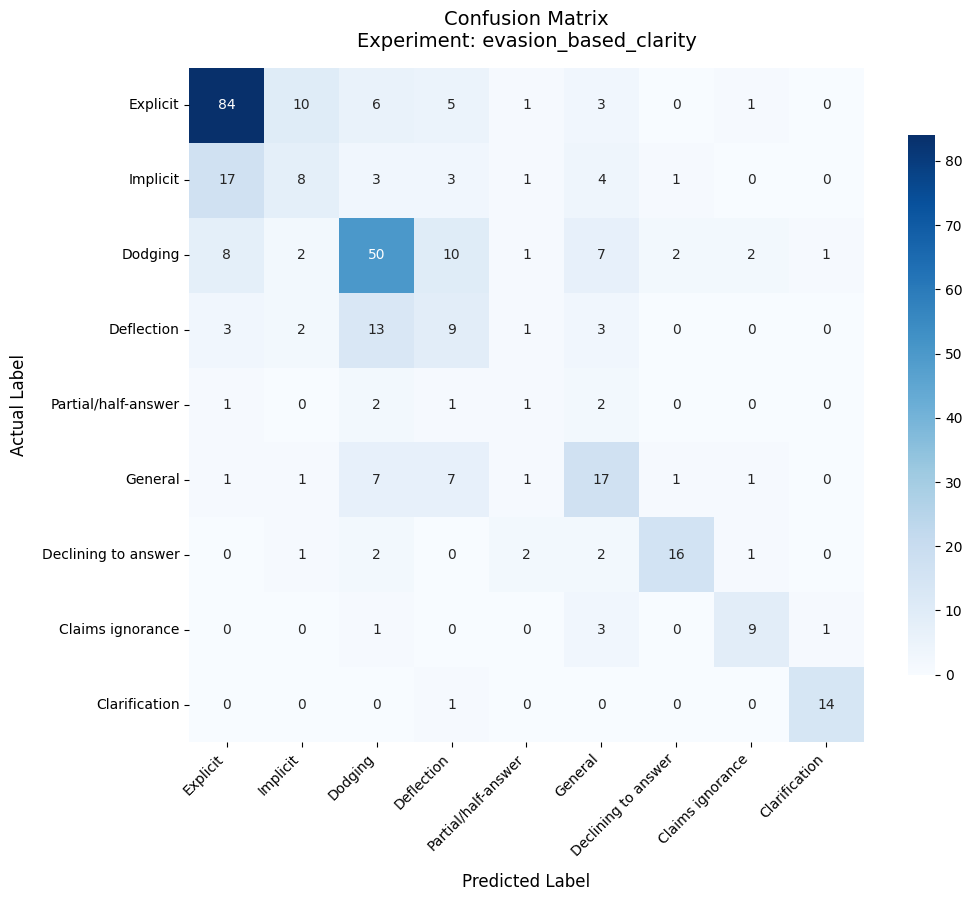

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total samples: 3448
Kept 1440 / 2758 samples after length filter
Kept 349 / 690 samples after length filter
Train labels: [1, 2, 1, 1, 1, 1, 1, 0, 0, 2, 2, 2, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 2, 2, 1, 2, 1, 1, 1, 2, 2, 2, 2, 1, 1, 2, 1, 1, 0, 2, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 2, 1, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1, 2, 1, 0, 1, 0, 2, 1, 0, 1, 1, 1, 0, 2, 2, 2, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 2, 2, 1, 2, 0, 1, 0, 0, 1, 1, 2, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 2, 0, 1, 0, 1, 2, 2, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 1, 1, 0, 0, 2, 0, 0, 0, 0, 1, 0, 1, 1, 1, 2, 1, 2, 1, 1, 0, 2, 0, 0, 1, 1, 2, 0, 1, 0, 1, 0, 2, 2, 1, 0, 1, 1, 0, 0, 0, 1, 1, 1, 0, 2, 1, 1, 1, 2, 2, 1, 1, 1, 1, 2, 0, 0, 0, 1, 1, 0, 2, 1, 1, 1, 2, 1, 1, 0, 1, 1, 1, 2, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 2, 0, 1, 1, 2, 1, 0, 0, 0, 1

Epoch 1/50 - Validation: 100%|██████████| 11/11 [00:06<00:00,  1.77it/s]


Epoch 1/50 — Train Loss: 0.9856 | Val Loss: 0.8392 | Macro F1: 0.4608


...

Epoch 12/50 — Train Loss: 0.1533 | Val Loss: 1.1979 | Macro F1: 0.7232


Epoch 13/50 - Validation: 100%|██████████| 11/11 [00:09<00:00,  1.16it/s]


Epoch 13/50 — Train Loss: 0.1450 | Val Loss: 1.3257 | Macro F1: 0.7274


Epoch 14/50 - Validation: 100%|██████████| 11/11 [00:05<00:00,  1.84it/s]


Epoch 14/50 — Train Loss: 0.1493 | Val Loss: 1.2984 | Macro F1: 0.7263
Early stopping: Train loss change 0.0043 is less than 0.005
Training finished. Best Macro F1: 0.7349. Model is saved at baseline-roberta-base-qaevasion-direct_clarity


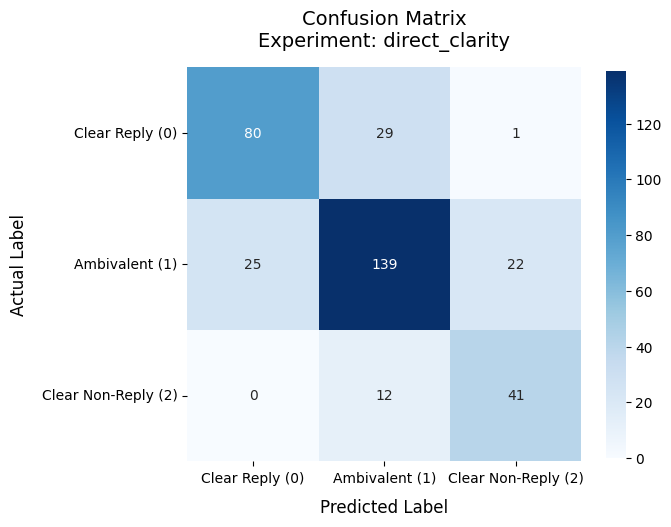

In [ ]:

run_experiment(
    experiment="evasion_based_clarity",
    model_name="roberta-base",
    dataset=ds,
    feature_setup="gpt3.5_summary"
)
gc.collect()
torch.cuda.empty_cache()


run_experiment(
    experiment="direct_clarity",
    model_name="roberta-base",
    dataset=ds,
    feature_setup="gpt3.5_summary"
)

gc.collect()
torch.cuda.empty_cache()

Running a baseline model that takes in (interview_question, interview_answer, question) as inputs for both evasion based classification, and direct clarity classification

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total samples: 3448
Kept 1757 / 2758 samples after length filter
Kept 430 / 690 samples after length filter
Train labels: [0, 2, 5, 3, 2, 2, 0, 1, 2, 0, 1, 0, 0, 5, 5, 0, 7, 5, 3, 2, 7, 0, 1, 0, 0, 8, 0, 2, 6, 0, 6, 0, 2, 2, 8, 4, 2, 0, 1, 0, 3, 2, 0, 0, 0, 0, 5, 2, 0, 2, 7, 1, 0, 3, 7, 5, 0, 2, 3, 2, 2, 1, 8, 2, 5, 0, 1, 0, 2, 1, 0, 5, 2, 1, 2, 7, 0, 8, 2, 0, 0, 1, 3, 1, 5, 8, 2, 0, 6, 2, 2, 2, 8, 5, 1, 3, 0, 3, 1, 5, 0, 0, 1, 2, 2, 2, 3, 0, 0, 0, 0, 4, 0, 8, 1, 2, 0, 3, 2, 0, 5, 3, 6, 4, 5, 4, 1, 0, 0, 3, 8, 3, 2, 0, 1, 6, 5, 2, 1, 1, 3, 0, 0, 6, 0, 2, 3, 0, 5, 3, 2, 2, 5, 2, 0, 2, 2, 0, 2, 0, 3, 0, 7, 2, 0, 0, 2, 2, 2, 2, 3, 6, 0, 2, 1, 2, 2, 1, 0, 2, 6, 2, 8, 8, 5, 0, 6, 5, 0, 6, 5, 6, 0, 8, 0, 3, 2, 0, 0, 2, 2, 0, 8, 1, 2, 2, 1, 2, 4, 7, 5, 1, 5, 0, 1, 7, 1, 7, 2, 4, 0, 8, 1, 0, 0, 6, 5, 0, 2, 6, 0, 2, 7, 2, 0, 1, 2, 2, 1, 0, 3, 0, 8, 0, 5, 0, 0, 2, 3, 0, 0, 2, 6, 2, 2, 7, 2, 2, 0, 0, 3, 0, 1, 2, 0, 0, 2, 5, 2, 0, 1, 5, 3, 2, 0, 1, 0, 1, 3, 0, 0, 0, 0, 5, 1, 5, 0, 5, 0, 4, 0, 1, 6

Epoch 1/50 - Validation: 100%|██████████| 14/14 [00:10<00:00,  1.30it/s]


Epoch 1/50 — Train Loss: 1.9536 | Val Loss: 1.8546 | Macro F1: 0.0633


...

Epoch 23/50 — Train Loss: 0.1995 | Val Loss: 2.9235 | Macro F1: 0.4515


Epoch 24/50 - Validation: 100%|██████████| 14/14 [00:07<00:00,  1.96it/s]


Epoch 24/50 — Train Loss: 0.1537 | Val Loss: 2.9236 | Macro F1: 0.4454


Epoch 25/50 - Validation: 100%|██████████| 14/14 [00:07<00:00,  1.97it/s]


Epoch 25/50 — Train Loss: 0.1565 | Val Loss: 3.0007 | Macro F1: 0.4688
Early stopping: Train loss change 0.0027 is less than 0.005
Training finished. Best Macro F1: 0.4688. Model is saved at basic_baseline-roberta-base-qaevasion-evasion_based_clarity


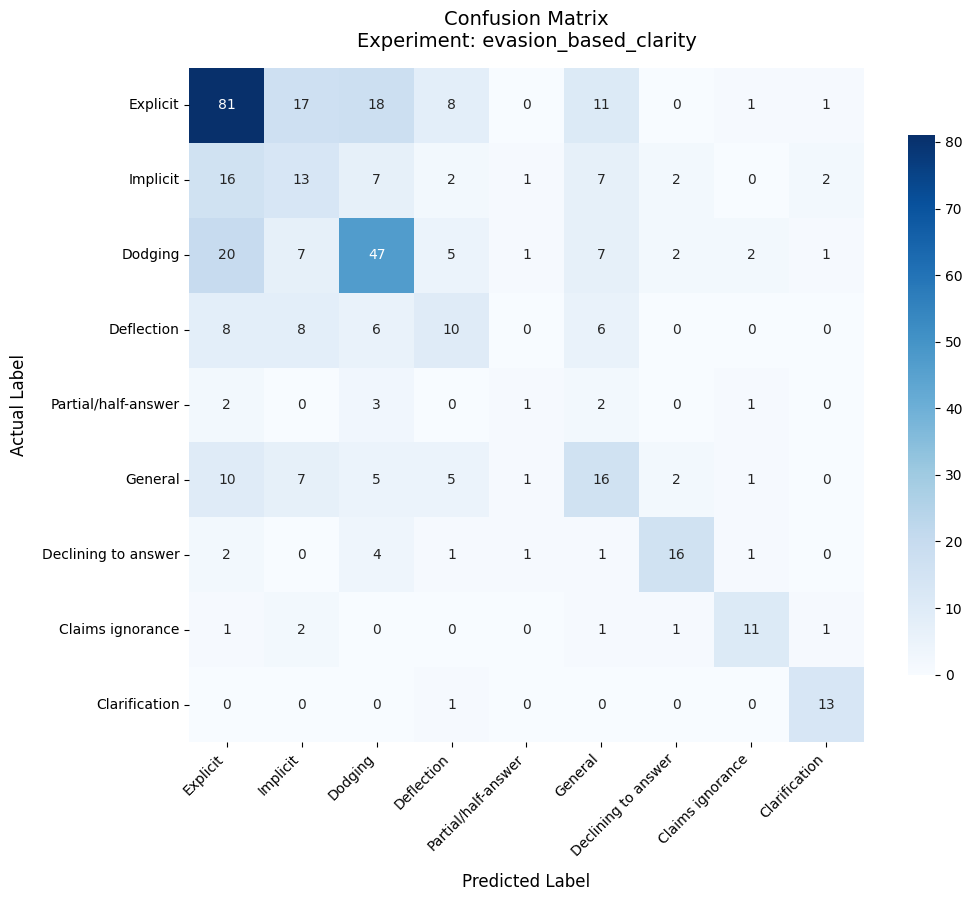

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total samples: 3448
Kept 1752 / 2758 samples after length filter
Kept 435 / 690 samples after length filter
Train labels: [1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 2, 2, 1, 2, 1, 0, 1, 1, 1, 1, 1, 1, 0, 2, 1, 1, 1, 1, 0, 2, 2, 1, 1, 2, 1, 1, 1, 2, 2, 2, 2, 1, 1, 1, 2, 1, 1, 0, 2, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0, 1, 2, 1, 0, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 2, 1, 1, 1, 0, 1, 0, 2, 1, 0, 1, 1, 1, 0, 2, 2, 2, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 2, 1, 2, 1, 1, 2, 1, 0, 1, 2, 0, 0, 1, 1, 1, 2, 1, 1, 1, 1, 0, 1, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 2, 0, 1, 0, 1, 2, 2, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 2, 1, 1, 0, 0, 2, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 2, 1, 0, 2, 1, 1, 0, 2, 0, 0, 1, 1, 2, 0, 1, 0, 1, 1, 0, 2, 2, 1, 0

Epoch 1/50 - Validation: 100%|██████████| 14/14 [00:11<00:00,  1.25it/s]


Epoch 1/50 — Train Loss: 0.9914 | Val Loss: 0.9538 | Macro F1: 0.2364


...

Epoch 12/50 — Train Loss: 0.2564 | Val Loss: 1.1122 | Macro F1: 0.6299


Epoch 13/50 - Validation: 100%|██████████| 14/14 [00:07<00:00,  1.79it/s]


Epoch 13/50 — Train Loss: 0.2215 | Val Loss: 1.3700 | Macro F1: 0.6348


Epoch 14/50 - Validation: 100%|██████████| 14/14 [00:07<00:00,  1.83it/s]


Epoch 14/50 — Train Loss: 0.2190 | Val Loss: 1.4062 | Macro F1: 0.6116
Early stopping: Train loss change 0.0025 is less than 0.005
Training finished. Best Macro F1: 0.6435. Model is saved at basic_baseline-roberta-base-qaevasion-direct_clarity


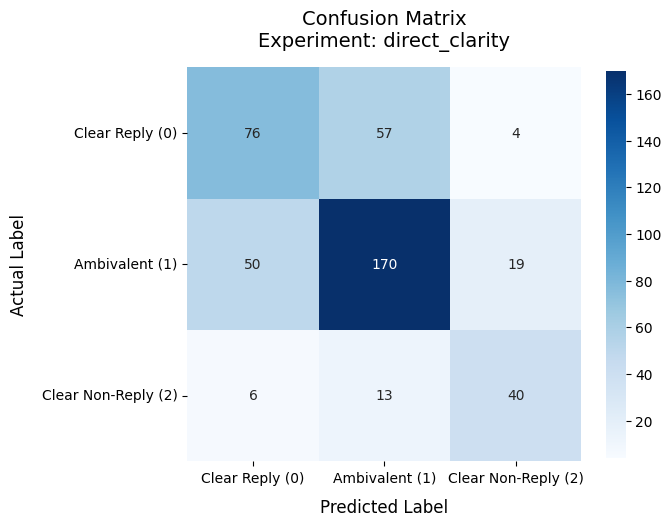

In [ ]:
run_experiment(
    experiment="evasion_based_clarity",
    model_name="roberta-base",
    dataset=ds,
    file_prefix = "basic_baseline"
)
gc.collect()
torch.cuda.empty_cache()

run_experiment(
    experiment="direct_clarity",
    model_name="roberta-base",
    dataset=ds,
    file_prefix = "basic_baseline"
)
gc.collect()
torch.cuda.empty_cache()

#RQ2

## a. augmentation of minority evasion label classes

In [ ]:
import json

LABEL_DEFINITIONS = {
    "Explicit": (
        "The information requested is explicitly stated (in the requested form). "
        "Example — Q: 'Do you have your own views about PR at Westminster?' A: 'I do.' "
        "The answer directly gives the information requested."
    ),
    "Implicit": (
        "The information requested is given, but without being explicitly stated (not in the expected form). "
        "Example — Q: 'Are you going to watch television?' A: 'What else is there to do?' "
        "They suggest planning to watch TV despite not explicitly stating it."
    ),
    "General": (
        "The information provided is too general or lacks the requested specificity. "
        "Example — Q: 'What is your favourite film?' A: 'Fight Club, Filth and Hereditary.' "
        "The reply gives three movies instead of one, making the desired information unclear."
    ),
    "Partial/half-answer": (
        "Offers only a specific component of the requested information, ignoring the rest. "
        "Example — Q: 'Did you enjoy the film?' A: 'The directing was great.' "
        "Directing is only part of what constitutes a film — the full question goes unanswered."
    ),
    "Dodging": (
        "Ignores the question altogether without any acknowledgment. "
        "Example — Q: 'Do you like my new dress?' A: 'We are late.' "
        "Does not even acknowledge the question and goes straight to another topic."
    ),
    "Deflection": (
        "Starts on topic but shifts focus and makes a different point than what is asked. "
        "Example — Q: 'Did you eat the last piece of pie?' A: 'I have to admit this was a great recipe, "
        "I always like it when there are chocolate chips in the dough.' "
        "Acknowledges the question but goes on a tangent without answering."
    ),
    "Declining to answer": (
        "Acknowledges the question but directly or indirectly refuses to answer. "
        "Example — Q: 'Wouldn't you regard that as a defeat?' A: 'I am not going to prophesy what will happen.' "
        "Directly states they will not answer."
    ),
    "Claims ignorance": (
        "The answerer claims or admits not to know the answer themselves. "
        "Example — Q: 'On what precise date did the government order the refit?' A: 'I do not know that date. "
        "I will find out and let the House know.' "
        "Explicitly claims they don't have the information."
    ),
    "Clarification": (
        "Does not provide the requested information and instead asks for clarification. "
        "Example — Q: 'Was it your decision to release the fund?' A: 'You mean the public fund?' "
        "Gives no data and asks for clarification instead."
    ),
}

CLARITY_MAPPING = {
    "Explicit": "Clear Reply",
    "Implicit": "Ambivalent",
    "Dodging": "Ambivalent",
    "General": "Ambivalent",
    "Deflection": "Ambivalent",
    "Partial/half-answer": "Ambivalent",
    "Declining to answer": "Clear Non-Reply",
    "Claims ignorance": "Clear Non-Reply",
    "Clarification": "Clear Non-Reply",
}



In [ ]:



def generate_samples(label, demonstrations, count, client):
    demo_text = ""

    for i, demo in enumerate(demonstrations):
        demo_text += f"""
Example {i+1}:
Full interview question: {demo['interview_question']}
Focused question: {demo['question']}
Answer: {demo['interview_answer']}
Summary: {demo['gpt3.5_summary']}
multiple_questions: {demo['multiple_questions']}
affirmative_questions: {demo['affirmative_questions']}
evasion_label: {demo['evasion_label']}
clarity_label: {demo['clarity_label']}
---"""

    prompt = f"""You are generating synthetic training data for a political interview evasion detection dataset.

Your task is to generate {count} realistic question-answer pairs from a fictional U.S. presidential press conference or interview.
Each generated sample must clearly exhibit the following evasion type:

Evasion label: {label}
Definition: {LABEL_DEFINITIONS[label]}

Here are real examples of this evasion type to guide your style and realism:
{demo_text}

Instructions:
- The interview_question should sound like a real journalist's question, grounded in plausible political topics (economy, foreign policy, healthcare, etc.).
- The interview_answer should sound like a real politician's response and must clearly exhibit the "{label}" evasion pattern.
- The question field should be a single focused sub-question extracted from interview_question.
- gpt3.5_summary that identifies and lists each distinct sub-question or point raised in the interview question.
- multiple_questions should be true if interview_question contains more than one sub-question, false otherwise.
- affirmative_questions should be true if the question is phrased affirmatively (e.g. "Wouldn't you agree...?"), false otherwise.
- Do NOT include title, date, president, url, annotator fields — leave them as empty strings or null.
- Do NOT include gpt3.5_prediction field.

Return JSON in this format:

{{
  "samples": [
    {{
      "interview_question": "...",
      "interview_answer": "...",
      "question": "...",
      "gpt3.5_summary": "...",
      "evasion_label": "{label}",
      "clarity_label": "{CLARITY_MAPPING[label]}",
      "multiple_questions": true,
      "affirmative_questions": false,
      "inaudible": false,
      "title": "",
      "date": "",
      "president": "",
      "url": "",
      "gpt3.5_prediction": "",
      "annotator_id": "",
      "annotator1": null,
      "annotator2": null,
      "annotator3": null
    }}
  ]
}}
"""

    response = client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "system",
                "content": (
                    "You generate high-quality synthetic NLP training data. "
                    "You always return valid JSON."
                )
            },
            {
                "role": "user",
                "content": prompt
            }
        ],
        response_format={"type": "json_object"},
        temperature=0.7
    )

    data = json.loads(response.choices[0].message.content)

    return data["samples"]

def get_demonstrations(count, label, dataset):
    df = pd.DataFrame(dataset)
    samples = df[df["evasion_label"] == label].sample(min(count, len(df[df["evasion_label"] == label])), random_state=42)
    return samples.to_dict("records")



In [ ]:
''''ds = load_dataset("ailsntua/QEvasion")
demos = get_demonstrations(2, "Partial/half-answer", ds["train"])
print(demos)'''

[{'title': "The President's News Conference", 'date': 'May 11, 2020', 'president': 'Donald J. Trump', 'url': 'https://www.presidency.ucsb.edu/documents/the-presidents-news-conference-1241', 'question_order': 5, 'interview_question': "Q. Mr. President, what are your thoughts about a second round of direct payments to Americans that's included in the House Democratic bill?", 'interview_answer': "Well, we're talking about that with a lot of different people. I want to see a payroll tax cut. I want to see various things that we want. I want the workers to be taken care of.But we are talking about that. We're negotiating with the Democrats. We'll see what happens. But as I said, it's a transition, and it's a—this is really going to be, in my opinion—we'll see, but I think it's going to be something that's going to be very special. It's a transition to greatness, and greatness is next year, right from the beginning. I think we're going to do fantastically well.I view the third quarter, as I 

In [ ]:
AUGMENT_TARGETS = {
    "Partial/half-answer": 320,
    "Clarification": 308,
    "Claims ignorance": 280,
    "Declining to answer": 255,
}

BATCH_SIZE = 5


def run_sample_generation():

    all_new_samples = []

    for label, target in AUGMENT_TARGETS.items():
        print(f"\nGenerating {target} samples for: {label}")
        demos = get_demonstrations(4, label, ds["train"])
        label_samples = []

        while len(label_samples) < target:
            remaining = target - len(label_samples)
            batch = min(BATCH_SIZE, remaining)
            try:
                new = generate_samples(label, demos, count=batch, client=client)
                label_samples.extend(new)
                print(f"  {len(label_samples)}/{target}")
            except Exception as e:
                print(f"  Error: {e}, continue")

        all_new_samples.extend(label_samples)
        print(f"✓ Done: {label}")

    # save
    aug_df = pd.DataFrame(all_new_samples)
    aug_df.to_csv("augmented_samples.csv", index=False)
    print(f"\nGenerated {len(aug_df)} new samples")
    print(aug_df["evasion_label"].value_counts())

    return aug_df

Changed the original run_experiment method that differentiates the validation dataset before appending the augmented data, to keep the testing only on original data.

In [ ]:
def run_augmented_experiment(experiment, model_name, train_records, val_records,
                   feature_setup="basic", plot_cm=True, file_prefix="augmented",
                   patience=3, min_delta=0.001):



    num_labels, label_map, tokenizer, model, max_size = configure(experiment, model_name)

    train_texts, train_labels = get_texts_and_labels(train_records, experiment, label_map, feature_setup)
    val_texts,   val_labels   = get_texts_and_labels(val_records,   experiment, label_map, feature_setup)

    print(f"Train samples: {len(train_texts)} | Val samples: {len(val_texts)}")

    train_dataset = EvasionDataset(train_texts, train_labels, tokenizer, max_length=max_size)
    val_dataset   = EvasionDataset(val_texts,   val_labels,   tokenizer, max_length=max_size)

    train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True,  collate_fn=collate_fn)
    val_dataloader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, collate_fn=collate_fn)

    print(f"Train batches: {len(train_dataloader)}, Val batches: {len(val_dataloader)}")

    optimizer = AdamW(model.parameters(), lr=1e-5)
    num_epochs = 20

    best_f1 = 0
    best_preds = None
    best_labels = None
    epochs_without_improvement = 0  # early stopping counter

    for epoch in range(num_epochs):
        # Training
        model.train()
        train_loss = 0.0
        for batch in tqdm(train_dataloader, desc=f'Epoch {epoch+1}/{num_epochs} - Training'):
            input_ids      = batch['input_ids'].to("cuda")
            attention_mask = batch['attention_mask'].to("cuda")
            labels         = batch['labels'].to("cuda")

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
            train_loss += loss.item()

        # Validation
        model.eval()
        val_loss = 0.0
        all_preds, all_labels_list = [], []

        with torch.no_grad():
            for batch in tqdm(val_dataloader, desc=f'Epoch {epoch+1}/{num_epochs} - Validation'):
                input_ids      = batch['input_ids'].to("cuda")
                attention_mask = batch['attention_mask'].to("cuda")
                labels         = batch['labels'].to("cuda")

                outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
                val_loss += outputs.loss.item()

                preds = torch.argmax(outputs.logits, dim=1)
                all_preds.extend(preds.cpu().numpy())
                all_labels_list.extend(labels.cpu().numpy())

        avg_train_loss = train_loss / len(train_dataloader)
        avg_val_loss   = val_loss   / len(val_dataloader)
        macro_f1       = f1_score(all_labels_list, all_preds, average='macro')

        print(f"Epoch {epoch+1}/{num_epochs} — Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Macro F1: {macro_f1:.4f}")

        # Early stopping check
        if macro_f1 > best_f1 + min_delta:
            best_f1 = macro_f1
            best_preds = all_preds
            best_labels = all_labels_list
            epochs_without_improvement = 0
            print(f"  ✓ New best F1: {best_f1:.4f}")
        else:
            epochs_without_improvement += 1
            print(f"  No improvement for {epochs_without_improvement}/{patience} epochs")
            if epochs_without_improvement >= patience:
                print(f"\nEarly stopping triggered at epoch {epoch+1}")
                break

    print(f"\nBest Macro F1: {best_f1:.4f}")

    # Save
    out_file = f"{file_prefix}-{model_name.split('/')[-1]}-qaevasion-{experiment}"
    model.save_pretrained(out_file)
    tokenizer.save_pretrained(out_file)
    print(f"Model saved to {out_file}")

    if plot_cm:
        plot_confusion_matrix(best_labels, best_preds, experiment)

    return best_f1

In [ ]:
def normalize_question(text):
    if text and not text.strip().startswith("Q."):
        return "Q. " + text.strip()
    return text

In [ ]:

ds = load_dataset("ailsntua/QEvasion")

orig_df = pd.DataFrame(ds["train"])
orig_train, orig_val = train_test_split(
    orig_df,
    test_size=0.4,
    random_state=42,
    stratify=orig_df["evasion_label"]
)

aug_df = pd.read_csv("augmented_samples.csv")
combined_train = pd.concat([orig_train, aug_df], ignore_index=True)

combined_train["interview_question"] = combined_train["interview_question"].apply(normalize_question)
orig_val["interview_question"] = orig_val["interview_question"].apply(normalize_question)


combined_train_records = combined_train.to_dict("records")
orig_val_records = orig_val.to_dict("records")  # real data only

print(f"Train: {len(combined_train_records)} (real + synthetic)")
print(f"Val:   {len(orig_val_records)} (real only)")
print("\nTrain distribution:")
print(combined_train["evasion_label"].value_counts())

Train: 3231 (real + synthetic)
Val:   1380 (real only)

Train distribution:
evasion_label
Explicit               631
Dodging                423
Partial/half-answer    367
Clarification          363
Claims ignorance       351
Declining to answer    342
Implicit               293
General                232
Deflection             229
Name: count, dtype: int64


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

...

Epoch 19/20 — Train Loss: 0.0938 | Val Loss: 3.5881 | Macro F1: 0.3680
  No improvement for 1/3 epochs


Epoch 20/20 - Validation: 100%|██████████| 28/28 [00:29<00:00,  1.04s/it]

Epoch 20/20 — Train Loss: 0.0879 | Val Loss: 3.7205 | Macro F1: 0.3865
  ✓ New best F1: 0.3865

Best Macro F1: 0.3865


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to augmented-roberta-base-qaevasion-evasion_based_clarity


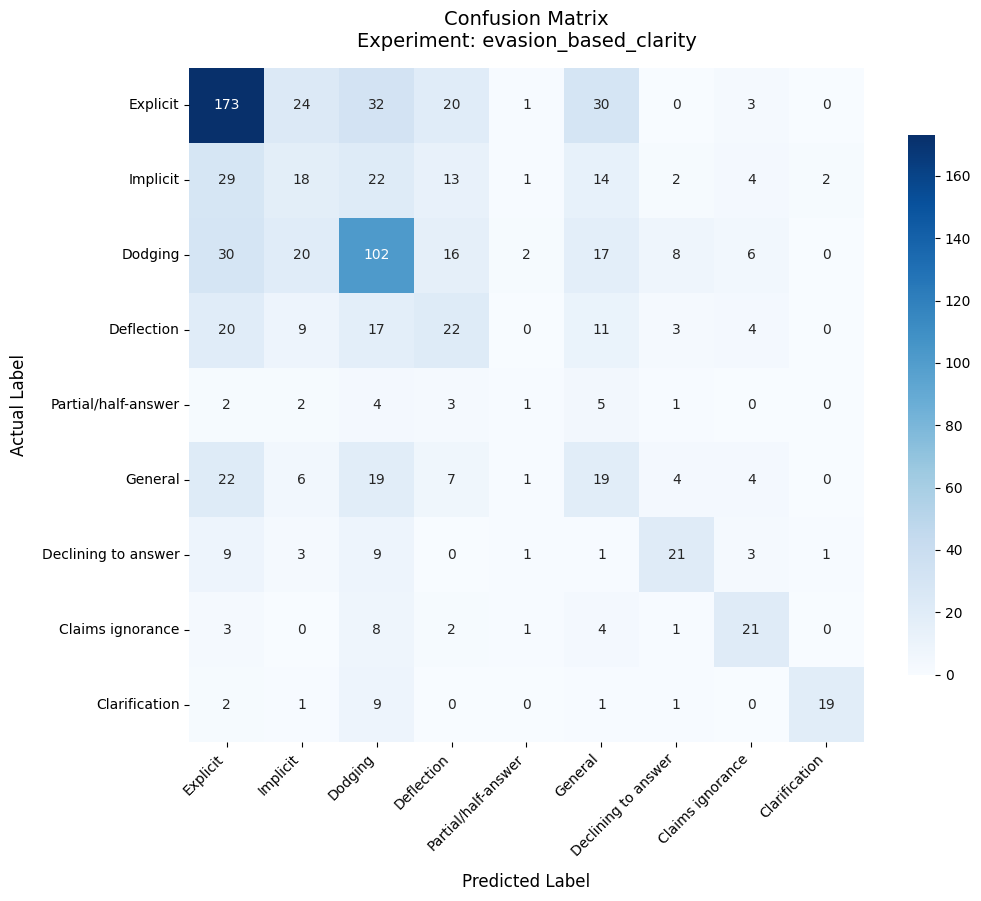

Augmented F1: 0.3865


In [ ]:

augmented_f1 = run_augmented_experiment(
    experiment="evasion_based_clarity",
    model_name="roberta-base",
    train_records=combined_train_records,
    val_records=orig_val_records,       # same val set for fair comparison,
    file_prefix="augmented"
)
print(f"Augmented F1: {augmented_f1:.4f}")



Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Train samples: 3231 | Val samples: 1380
Kept 2454 / 3231 samples after length filter
Kept 896 / 1380 samples after length filter
Train batches: 154, Val batches: 28


Epoch 1/20 - Validation: 100%|██████████| 28/28 [00:29<00:00,  1.04s/it]


Epoch 1/20 — Train Loss: 0.7203 | Val Loss: 0.9733 | Macro F1: 0.3373
  ✓ New best F1: 0.3373


...

Epoch 9/20 — Train Loss: 0.1568 | Val Loss: 1.4388 | Macro F1: 0.6197
  No improvement for 2/3 epochs


Epoch 10/20 - Validation: 100%|██████████| 28/28 [00:29<00:00,  1.04s/it]

Epoch 10/20 — Train Loss: 0.1325 | Val Loss: 1.6920 | Macro F1: 0.6150
  No improvement for 3/3 epochs

Early stopping triggered at epoch 10

Best Macro F1: 0.6277


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to augmented-roberta-base-qaevasion-direct_clarity


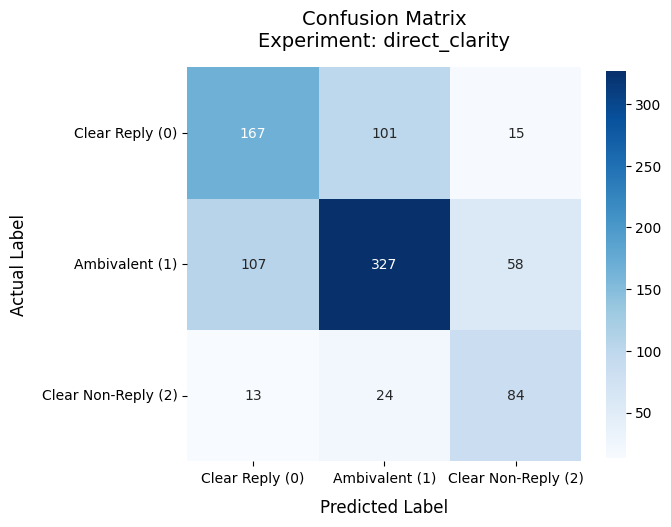

Augmented F1: 0.6277


In [ ]:
augmented_f1 = run_augmented_experiment(
    experiment="direct_clarity",
    model_name="roberta-base",
    train_records=combined_train_records,
    val_records=orig_val_records,       # same val set for fair comparison,
    file_prefix="augmented"
)
print(f"Augmented F1: {augmented_f1:.4f}")

In [ ]:
ds = load_dataset("ailsntua/QEvasion")

orig_df = pd.DataFrame(ds["train"])
orig_train, orig_val = train_test_split(
    orig_df,
    test_size=0.3,
    random_state=42,
    stratify=orig_df["evasion_label"]
)

filt_aug_df = pd.read_csv("augmented_samples_filtered.csv")
filt_combined_train = pd.concat([orig_train, filt_aug_df], ignore_index=True)

filt_combined_train["interview_question"] = filt_combined_train["interview_question"].apply(normalize_question)
orig_val["interview_question"] = orig_val["interview_question"].apply(normalize_question)


filt_combined_train_records = filt_combined_train.to_dict("records")
orig_val_records = orig_val.to_dict("records")  # real data only

print(f"Train: {len(filt_combined_train_records)} (real + synthetic)")
print(f"Val:   {len(orig_val_records)} (real only)")
print("\nTrain distribution:")
print(filt_combined_train["evasion_label"].value_counts())

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Train samples: 2952 | Val samples: 1380
Kept 2175 / 2952 samples after length filter
Kept 896 / 1380 samples after length filter
Train batches: 136, Val batches: 28


Epoch 1/20 - Validation: 100%|██████████| 28/28 [00:29<00:00,  1.05s/it]


Epoch 1/20 — Train Loss: 1.7768 | Val Loss: 1.8649 | Macro F1: 0.1071
  ✓ New best F1: 0.1071


...

Epoch 13/20 — Train Loss: 0.2538 | Val Loss: 2.4378 | Macro F1: 0.3671
  No improvement for 2/3 epochs


Epoch 14/20 - Validation: 100%|██████████| 28/28 [00:29<00:00,  1.04s/it]

Epoch 14/20 — Train Loss: 0.2328 | Val Loss: 2.6501 | Macro F1: 0.3607
  No improvement for 3/3 epochs

Early stopping triggered at epoch 14

Best Macro F1: 0.3829


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to filt_augmented-roberta-base-qaevasion-evasion_based_clarity


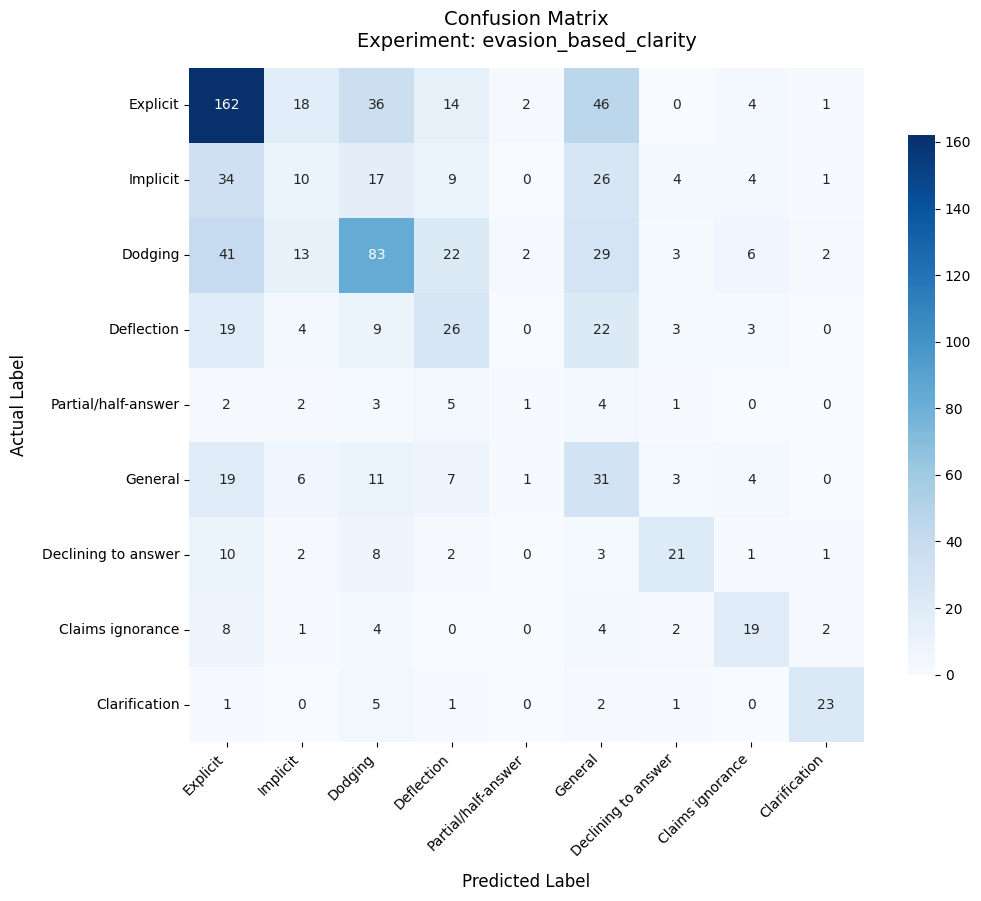

Augmented F1: 0.3829


In [ ]:
augmented_f1 = run_augmented_experiment(
    experiment="evasion_based_clarity",
    model_name="roberta-base",
    train_records=filt_combined_train_records,
    val_records=orig_val_records,       # same val set for fair comparison,
    file_prefix="filt_augmented"
)
print(f"Augmented F1: {augmented_f1:.4f}")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.bias              | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.weight         | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Train samples: 2952 | Val samples: 1380
Kept 2175 / 2952 samples after length filter
Kept 896 / 1380 samples after length filter
Train batches: 136, Val batches: 28


Epoch 1/20 - Validation: 100%|██████████| 28/28 [00:29<00:00,  1.04s/it]


Epoch 1/20 — Train Loss: 0.7714 | Val Loss: 0.9251 | Macro F1: 0.2530
  ✓ New best F1: 0.2530


...

Epoch 6/20 — Train Loss: 0.2344 | Val Loss: 1.0483 | Macro F1: 0.6092
  No improvement for 2/3 epochs


Epoch 7/20 - Validation: 100%|██████████| 28/28 [00:28<00:00,  1.00s/it]

Epoch 7/20 — Train Loss: 0.1776 | Val Loss: 1.2488 | Macro F1: 0.6125
  No improvement for 3/3 epochs

Early stopping triggered at epoch 7

Best Macro F1: 0.6276


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to filt_augmented-roberta-base-qaevasion-direct_clarity


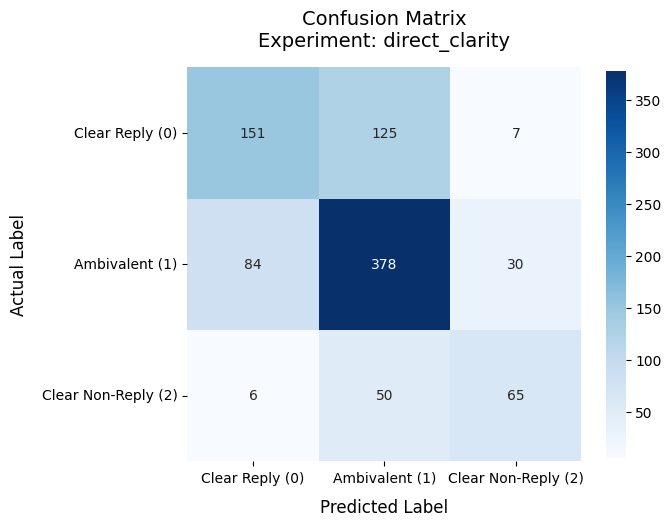

Augmented F1: 0.6276


In [ ]:
augmented_f1 = run_augmented_experiment(
    experiment="direct_clarity",
    model_name="roberta-base",
    train_records=filt_combined_train_records,
    val_records=orig_val_records,       # same val set for fair comparison,
    file_prefix="filt_augmented"
)
print(f"Augmented F1: {augmented_f1:.4f}")

## b. improved summaries


In [ ]:
def generate_summary(question, interview_question, interview_answer, client):

    prompt = f"""You are an expert political discourse analyst. Given a question and answer from a presidential interview, produce a structured summary that:
1. Identifies and lists each distinct sub-question or point raised in the interview question.
2. For each sub-question, summarizes what information the answer provides (or fails to provide) in relation to it.
3. Notes any relevant context or additional points made in the answer.
4. Notes whether the answer addresses each point directly or sidesteps/avoids it, without making judgments.

Keep each coverage explanation to 1–3 sentences. Do not repeat the interview answer verbatim.
Be precise, neutral, and faithful to the content. Do not use evaluative language like "directly responds" or "explicitly states". Do not infer intent beyond what is stated. Be especially careful to decompose all sub-questions.

Specific question being analyzed:
{question}

Full interview question (may contain multiple parts):
{interview_question}

Interview answer:
{interview_answer}

Provide the summary in the following format:
Question part 1: [sub-question]
Answer coverage: [what the answer says about this, and whether the answer contains information responsive to the question, partially responsive information, or no responsive information]

Question part 2: [sub-question]
Answer coverage: [what the answer says about this, and whether the answer contains information responsive to the question, partially responsive information, or no responsive information]

(continue for all parts)

Additional context: [any relevant points made in the answer beyond the questions asked, or "None"]"""

    response = client.chat.completions.create(
        model="gpt-5.4-nano",
        messages=[{"role": "user", "content": prompt}],
        temperature=0.0,
    )
    return response.choices[0].message.content


def upgrade_dataset_summaries(ds_split, split_name="*"):
    records = []
    errors = []

    summaryClient = OpenAI()

    for i, sample in enumerate(ds_split):
        if i % 100 == 0:
            print(f"[{split_name}] Processing {i}/{len(ds_split)}...")

        try:
            new_summary = generate_summary(
                question=sample["question"],
                interview_question=sample["interview_question"],
                interview_answer=sample["interview_answer"],
                client=summaryClient
            )
            record = dict(sample)
            record["5.4-nano_summary"] = new_summary
            records.append(record)

        except Exception as e:
            print(f"[{split_name}] Error at index {i}: {e}")
            errors.append(i)
            record = dict(sample)
            record["5.4-nano_summary"] = None
            records.append(record)
            time.sleep(5)

        time.sleep(0.1)

    print(f"[{split_name}] Done. Errors: {len(errors)} at indices: {errors}")
    return records

Example on the first 5 questions in the train set

In [ ]:
from google.colab import drive
import os

ds = load_dataset("ailsntua/QEvasion")
test_samples = list(ds["train"].select(range(5)))

testtest = upgrade_dataset_summaries(test_samples)
testtest_df = pd.DataFrame(testtest)

[*] Processing 0/5...
[*] Done. Errors: 0 at indices: []


In [ ]:
drive.mount('/content/drive')
save_path = "/content/drive/MyDrive/data/"
os.makedirs(save_path, exist_ok=True)


testtest_df.to_parquet(os.path.join(save_path, "summarization_test.parquet"), index=False)
print("Saved to Google Drive!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Saved to Google Drive!


examples

In [ ]:
for summary in testtest_df["5.4-nano_summary"]:
    print(summary)
    print(400 * "=")

Question part 1: Respond to the accusation that the U.S. is “containing China” while pushing for diplomatic talks  
Answer coverage: The answer frames the trip as “less about containing China,” stating “I don’t want to contain China.” It describes the goal as having a “relationship with China that is on the up and up” and “squared away,” and says one way to do that is to “make sure that we are talking about the same things.” It also characterizes the approach as maintaining stability and adhering to “international rules of the road,” rather than isolating China.

Question part 2: Address whether the U.S. is pushing diplomatic talks despite “containing” China  
Answer coverage: The answer references “talking with President Xi” and says the relationship is being pursued with the aim of getting it “right.” It does not present a specific diplomatic proposal or negotiation framework, but it links diplomacy to aligning on issues and rules (“talking about the same things,” “rules of the road…

comparison of the first one

In [ ]:
print(40 * "=", "new summary", 40 * "=")
print(testtest_df["5.4-nano_summary"][0])
print(40 * "=", "old summary", 40 * "=")
print(testtest_df["gpt3.5_summary"][0])

======================================== new summary ========================================
Question part 1: Respond to the accusation that the U.S. is “containing China” while pushing for diplomatic talks  
Answer coverage: The answer frames the trip as “less about containing China,” stating “I don’t want to contain China.” It describes the goal as having a “relationship with China that is on the up and up” and “squared away,” and says one way to do that is to “make sure that we are talking about the same things.” It also characterizes the approach as maintaining stability and adhering to “international rules of the road,” rather than isolating China.

Question part 2: Address whether the U.S. is pushing diplomatic talks despite “containing” China  
Answer coverage: The answer references “talking with President Xi” and says the relationship is being pursued with the aim of getting it “right.” It does not present a specific diplomatic proposal or negotiation framework, but it links d

In [ ]:
import os
save_path = "/home/lukaspiljak/Faks/APT/"
os.makedirs(save_path, exist_ok=True)

train_path = os.path.join(save_path, "train_dataset_gpt54-nano_summaries.parquet")
test_path = os.path.join(save_path, "test_dataset_gpt54-nano_summaries.parquet")

ds = load_dataset("ailsntua/QEvasion")

if os.path.exists(train_path) and os.path.exists(test_path):
    print("Loading existing summaries from parquet files...")
    train_summaries_df = pd.read_parquet(train_path)
    test_summaries_df = pd.read_parquet(test_path)
else:
    print("Generating new summaries...")
    train_records = upgrade_dataset_summaries(ds["train"], "train")
    train_summaries_df = pd.DataFrame(train_records)
    train_summaries_df.to_parquet(train_path, index=False)
    print("Saved train dataset")

    test_records = upgrade_dataset_summaries(ds["test"], "test")
    test_summaries_df = pd.DataFrame(test_records)
    test_summaries_df.to_parquet(test_path, index=False)
    print("Saved test dataset")

train_dataset = HFDataset.from_pandas(train_summaries_df)
test_dataset = HFDataset.from_pandas(test_summaries_df)

updated_ds = DatasetDict({
    'train': train_dataset,
    'test': test_dataset
})

print("Updated DatasetDict created with train and test splits:")
print(updated_ds)
print(updated_ds['train'][0])

Loading existing summaries from parquet files...
Updated DatasetDict created with train and test splits:
DatasetDict({
    train: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label', '5.4-nano_summary'],
        num_rows: 3448
    })
    test: Dataset({
        features: ['title', 'date', 'president', 'url', 'question_order', 'interview_question', 'interview_answer', 'gpt3.5_summary', 'gpt3.5_prediction', 'question', 'annotator_id', 'annotator1', 'annotator2', 'annotator3', 'inaudible', 'multiple_questions', 'affirmative_questions', 'index', 'clarity_label', 'evasion_label', '5.4-nano_summary'],
        num_rows: 308
    })
})
{'title': "The President's News Conference in Hanoi, Vietnam", 'date': 'Septembe

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total samples: 3448
Kept 1114 / 2758 samples after length filter
Kept 275 / 690 samples after length filter
Train labels: [0, 2, 2, 0, 2, 0, 0, 5, 0, 7, 5, 3, 7, 0, 8, 2, 0, 6, 2, 2, 8, 4, 2, 0, 0, 3, 2, 0, 5, 7, 0, 3, 2, 2, 2, 1, 8, 0, 2, 1, 0, 2, 1, 2, 7, 0, 8, 2, 0, 1, 8, 2, 0, 6, 2, 2, 8, 5, 3, 0, 3, 1, 0, 2, 2, 0, 4, 8, 2, 0, 2, 0, 6, 4, 0, 0, 8, 3, 2, 0, 1, 6, 2, 1, 1, 0, 6, 2, 3, 0, 2, 5, 2, 0, 2, 0, 0, 0, 0, 2, 2, 2, 3, 6, 2, 2, 2, 1, 0, 6, 8, 8, 5, 6, 5, 6, 6, 8, 0, 2, 0, 2, 0, 8, 2, 2, 2, 7, 7, 5, 7, 2, 4, 0, 8, 6, 5, 0, 2, 6, 0, 2, 7, 2, 0, 2, 1, 8, 0, 5, 0, 2, 0, 3, 0, 0, 2, 2, 7, 0, 0, 0, 1, 2, 0, 0, 2, 5, 0, 1, 5, 2, 0, 1, 1, 3, 0, 1, 5, 0, 5, 0, 4, 0, 6, 2, 0, 7, 1, 0, 6, 8, 4, 0, 2, 3, 0, 7, 0, 3, 1, 2, 0, 6, 2, 0, 0, 0, 8, 7, 2, 2, 5, 0, 0, 0, 2, 2, 6, 4, 1, 2, 6, 7, 0, 2, 6, 0, 5, 2, 0, 5, 0, 6, 7, 5, 6, 2, 1, 6, 8, 2, 6, 3, 2, 2, 0, 5, 2, 0, 2, 0, 0, 3, 8, 2, 0, 0, 3, 6, 0, 2, 6, 7, 5, 7, 2, 2, 0, 0, 0, 5, 1, 0, 7, 2, 2, 0, 0, 0, 2, 5, 2, 5, 2, 3, 0, 5, 0, 3, 5, 0, 2

Epoch 1/50 - Validation: 100%|██████████| 9/9 [00:34<00:00,  3.80s/it]


Epoch 1/50 — Train Loss: 1.9311 | Val Loss: 1.9138 | Macro F1: 0.0825


...

Epoch 17/50 — Train Loss: 0.1435 | Val Loss: 2.3370 | Macro F1: 0.4431


Epoch 18/50 - Validation: 100%|██████████| 9/9 [00:33<00:00,  3.67s/it]


Epoch 18/50 — Train Loss: 0.0957 | Val Loss: 2.3109 | Macro F1: 0.4215


Epoch 19/50 - Validation: 100%|██████████| 9/9 [00:31<00:00,  3.54s/it]


Epoch 19/50 — Train Loss: 0.0971 | Val Loss: 2.5863 | Macro F1: 0.4561
Early stopping: Train loss change 0.0014 is less than 0.005
Training finished. Best Macro F1: 0.4561. Model is saved at baseline-roberta-base-qaevasion-evasion_based_clarity


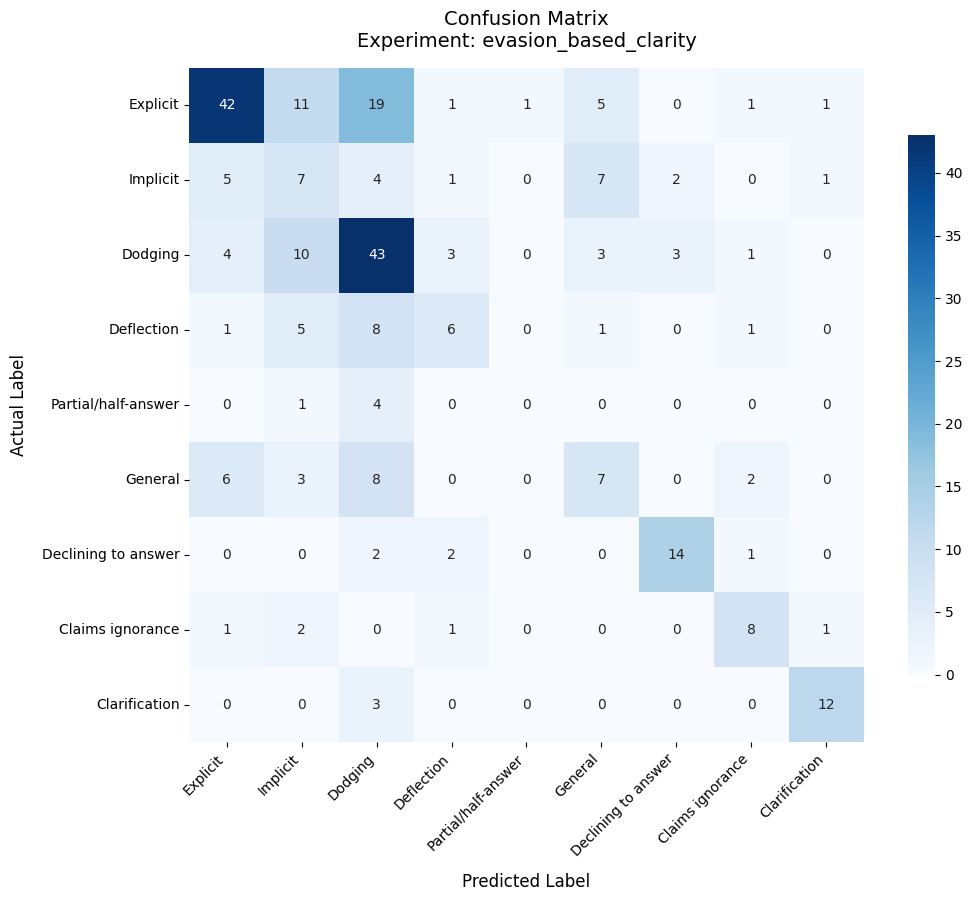

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base
Key                        | Status     | 
---------------------------+------------+-
lm_head.dense.weight       | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.dense.bias      | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total samples: 3448
Kept 1123 / 2758 samples after length filter
Kept 266 / 690 samples after length filter
Train labels: [1, 2, 1, 1, 1, 1, 0, 2, 2, 2, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 2, 2, 1, 2, 1, 1, 1, 2, 2, 2, 2, 1, 2, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 2, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 2, 1, 0, 1, 1, 2, 1, 1, 1, 0, 1, 1, 0, 1, 2, 0, 1, 0, 2, 1, 0, 1, 1, 0, 2, 2, 1, 0, 0, 1, 1, 0, 0, 2, 2, 1, 2, 0, 1, 0, 1, 2, 1, 1, 1, 1, 0, 1, 2, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 2, 1, 0, 1, 2, 2, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 0, 0, 1, 1, 2, 1, 2, 1, 1, 0, 2, 0, 0, 1, 1, 2, 1, 1, 0, 2, 2, 1, 0, 1, 1, 0, 0, 1, 1, 0, 2, 1, 2, 2, 1, 1, 1, 2, 0, 1, 2, 1, 1, 1, 0, 1, 2, 1, 0, 1, 0, 1, 1, 1, 1, 2, 0, 1, 1, 1, 0, 0, 2, 1, 1, 2, 1, 0, 0, 0, 2, 2, 2, 1, 1, 1, 1, 1, 0, 0, 2, 1, 0, 0, 0, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 1, 1, 1, 1, 0, 2, 1, 1, 0, 1, 0, 0, 1, 2, 1, 1, 2, 2, 0, 1, 1, 2, 1, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0

Epoch 1/50 - Validation: 100%|██████████| 9/9 [00:33<00:00,  3.76s/it]


Epoch 1/50 — Train Loss: 1.0350 | Val Loss: 1.0054 | Macro F1: 0.2233


...

Epoch 15/50 — Train Loss: 0.0817 | Val Loss: 2.0635 | Macro F1: 0.6763


Epoch 16/50 - Validation: 100%|██████████| 9/9 [00:30<00:00,  3.42s/it]


Epoch 16/50 — Train Loss: 0.0312 | Val Loss: 2.2089 | Macro F1: 0.6840


Epoch 17/50 - Validation: 100%|██████████| 9/9 [00:31<00:00,  3.45s/it]


Epoch 17/50 — Train Loss: 0.0294 | Val Loss: 2.1334 | Macro F1: 0.6829
Early stopping: Train loss change 0.0018 is less than 0.005
Training finished. Best Macro F1: 0.6960. Model is saved at baseline-roberta-base-qaevasion-direct_clarity


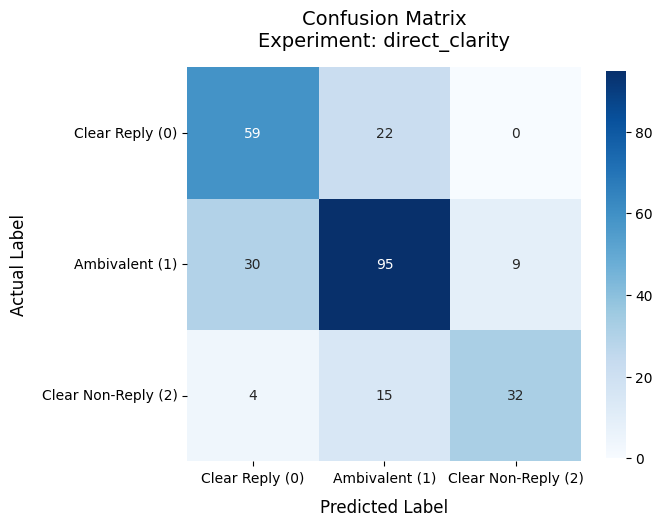

In [ ]:

run_experiment(
    experiment="evasion_based_clarity",
    model_name="roberta-base",
    dataset=updated_ds,
    feature_setup="5.4-nano_summary",
    num_epochs=50
)
gc.collect()
torch.cuda.empty_cache()


run_experiment(
    experiment="direct_clarity",
    model_name="roberta-base",
    dataset=updated_ds,
    feature_setup="5.4-nano_summary",
    num_epochs=50
)
gc.collect()
torch.cuda.empty_cache()

#RQ3